# NOTEBOOK PRÁCTICA COMPLEJOS SIMPLICIALES

Información sobre los headers de las funciones:
Las funciones xx_aux() se usan para calcular xx y devolver el resultado.
Las funciones xx() se usan para imprimir el resultado de xx_aux().
A excepción de caras_por_dimension() que usa n_caras() como auxiliar.
De esta forma, si se quiere usar el resultado de xx en otro código,
se puede usar xx_aux() sin que imprima nada por pantalla.

## ACLARACIÓN IMPORTANTE
Para este notebook, como tenemos varias funciones de distintas prácticas hechas en la misma clase, lo que hemos hecho en el notebook es importar el archivo simplice.py para poder ejecutar los ejemplos paso a paso, y encima ponemos el código correspondiente, aunque no es ese el que se ejecuta, es el que está en el archivo simplice.py. Por ello, solo hay que ejecutar las celdas que ejecutan el ejemplo, no las celdas en las que aparece el código de cada función ya que darán error.

### IMPORTS USADOS:

In [ ]:
# Para crear las caras dados los vertices de un simplice
from itertools import combinations
import numpy as np
# Bibliotecas usadas en los ejemplos de Voronoi y Delaunay
from scipy.spatial import Delaunay,Voronoi, voronoi_plot_2d
# Bibliotecas para las gráficas de los alfa complejos
import matplotlib.pyplot as plt
import matplotlib.colors

## PRÁCTICA 1: EJERCICIOS CLASE 1 Y CLASE 2
### CLASE SIMPLICE:

In [ ]:
class Simplice:
    def __init__(self, vertices):
        vert = []
        for v in vertices:
            try:
                vert.append(int(v))
            except Exception:
                vert.append(v)
        self.vertices = vert
        self.caras = self.calcular_caras()
        self.dimension = len(vertices) - 1

    def calcular_caras(self):
        caras = set()
        n = len(self.vertices)
        for k in range(1, n + 1):
            # Para calcular las caras del símplice, vemos todas las posibles combinaciones que se pueden
            # formar con los vértices, para ello se utiliza el paquete combinations
            for cara in combinations(self.vertices, k):
                caras.add(tuple(cara))
        return caras

### CLASE COMPLEJO SIMPLICIAL

In [ ]:
class Complejo_simplicial:
    def __init__(self, simplices):
        self.simplices = self.calcular_simplices(simplices)
        self.c = self.calcular_caras()
        # La dimensión del complejo simplicial es la dimensión máxima de los símplices
        self.d = max(s.dimension for s in simplices) if simplices else 0

    # Método para calcular los símplices maximales del complejo simplicial
    def calcular_simplices(self, simplices):
        maximal_simplices = set()
        for s in simplices:
            # Evitamos añadir símplices repetidos, comprobando si tiene los mismos vértices
            if any(set(s.vertices) == set(existing.vertices) for existing in maximal_simplices):
                continue
            # Eliminamos las caras que ya estén contenidas en el simplice que queremos añadir
            to_remove = [existing for existing in maximal_simplices if set(existing.vertices).issubset(set(s.vertices))]
            for r in to_remove:
                maximal_simplices.remove(r)
            maximal_simplices.add(s)
        return maximal_simplices


### FUNCIÓN PARA CALCULAR LAS CARAS DEL COMPLEJO:

In [ ]:
# Definimos las caras del complejo simplicial usando las caras de los símplices maximales
    def calcular_caras(self):
        caras = set()
        # Añadimos las caras de cada símplice. Las caras de cada símplice ya las calculamos en la clase Simplice
        for s in self.simplices:
            for cara in s.caras:
                if cara not in caras:  # Evitamos tener caras duplicadas, importante para los complejos simpliciales filtrados
                    caras.add(cara)
        return sorted(caras, key=lambda x: x) # lambda expression que ordena las caras por su valor inicial

    def print_caras(self):
        print(f"Caras del complejo: {self.c}")

### Ejemplo 1
Consideramos el 3-símplice (0,1,2,3)

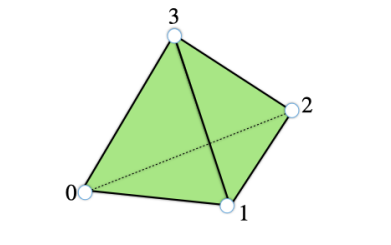


In [2]:
# Importamos el archivo que contiene todo nuestro código como ya hemos explicado en la aclaración:
from simplices import *
# Creamos el complejo simplicial
complejo = Complejo_simplicial([Simplice([0,1,2,3])])
complejo.print_caras()

Caras del complejo: [(0,), (0, 1), (0, 1, 2), (0, 1, 2, 3), (0, 1, 3), (0, 2), (0, 2, 3), (0, 3), (1,), (1, 2), (1, 2, 3), (1, 3), (2,), (2, 3), (3,)]


### DIMENSIÓN DEL COMPLEJO:
La calculamos en el constructor del complejo

In [ ]:
def dimension(self):
    print(f"Dimensión del complejo: {self.d}")
# En nuestro ejemplo:

In [2]:
# En nuestro ejemplo:
complejo.dimension()

Dimensión del complejo: 3


### FUNCIÓN PARA CALCULAR LAS CARAS DE DIMENSIÓN N:

In [ ]:
    # Este metodo permite extraer las caras de dimensión n
def n_caras(self, n):
    if n < 0 or n > self.d:
        print(f"No hay caras de dimensión {n} en el complejo.")
        return []
    else:
        # Miramos en nuestro atributo c (Caras del complejo simplicial) si tienen dimensión n y la añadimos
        caras_n = sorted(set([cara for cara in self.c if len(cara) == n+1]), key=lambda x: x)
    return caras_n

    # Calculamos el número de caras por dimensión
def caras_por_dimension(self):
    # Nos vamos cogiendo todas las caras de dimensión i con el metodo ya creado de n_caras
    caras_dim = [self.n_caras(i) for i in range(self.d + 1)]
    for i in range(self.d + 1):
        print(f"Caras de dimensión {i}: {caras_dim[i]}")
    return caras_dim



In [3]:
complejo.caras_por_dimension()

Caras de dimensión 0: [(0,), (1,), (2,), (3,)]
Caras de dimensión 1: [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
Caras de dimensión 2: [(0, 1, 2), (0, 1, 3), (0, 2, 3), (1, 2, 3)]
Caras de dimensión 3: [(0, 1, 2, 3)]


### FUNCIÓN PARA CALCULAR LA CARACTER

In [ ]:
    # Cálculo de la característica de Euler
    def Euler(self):
        chi = 0
        # Definimos el sumatorio para la característica de Euler
        for i in range(self.d + 1):
            # Calculamos el número de caras de cada dimensión, las de dimensión para se suman
            # y las de dimensión impar se restan, obteniendo así la característica de Euler
            chi += (-1) ** i * len(self.n_caras(i))
        print(f"Característica de Euler: {chi}")
        return chi

In [4]:
complejo.Euler()

Característica de Euler: 1


1

### FUNCIÓN PARA CALCULAR LA ESTRELLA DE UN SÍMPLICE

In [ ]:
    # La estrella de un símplice c es el conjunto de todas las cocaras de c
    def estrella_aux(self, c):
        estrella = set([cara for cara in self.c if set(c).issubset(set(cara))])
        estrella = sorted(estrella, key=lambda x: x)
        return estrella

    # Usamos la función auxiliar para calcular la estrella y luego la imprimimos
    def estrella(self, c):
        # Todas las caras que contienen a c
        estrella = self.estrella_aux(c)
        print(f"Estrella de {c}: {estrella}")

In [5]:
complejo.estrella([0,1])

Estrella de [0, 1]: [(0, 1), (0, 1, 2), (0, 1, 2, 3), (0, 1, 3)]


### FUNCIONES PARA CALCULAR EL LINK DE UN SÍMPLICE:

In [ ]:
# La estrella cerrada de c es el menor subcomplejo de K que contiene a la estrella de c.
    def estrella_cerrada_aux(self, c):
        # Encuentra todas las caras que contienen al menos un vértice de c
        caras_con_v = [cara for cara in self.c if any(v in cara for v in c)]
        # Se podria hacer utilizando las caras que devuelve la funcion estrella,
        # pero nos es mas intuitivo partir desde cero
        # Añade todas las subcaras de esas caras
        estrella_cerrada = set()
        for cara in caras_con_v:
            for k in range(1, len(cara) + 1):
                for subcara in combinations(cara, k):
                    estrella_cerrada.add(tuple(sorted(subcara)))
        estrella_cerrada = sorted(estrella_cerrada, key=lambda x: x)
        return estrella_cerrada

    # Usamos la función auxiliar para calcular la estrella cerrada
    # y luego la imprimimos
    def estrella_cerrada(self, c):
        estrella_cerrada = self.estrella_cerrada_aux(c)
        print(f"Estrella cerrada de {c}: {estrella_cerrada}")
        return estrella_cerrada

    # El link de un símplice c es el conjunto de todos los símplices de la estrella cerrada de c
    # cuya intersección con la estrella de c es vacía
    def link_aux(self, c):
        estrella_cerrada = self.estrella_cerrada_aux(c)
        estrella = self.estrella_aux(c)
        link = [cara for cara in estrella_cerrada if cara not in estrella]
        return link

    # Usamos la función auxiliar para calcular el link
    # y luego la imprimimos
    def link(self, c):
        link = self.link_aux(c)
        print(f"Link de {c}: {link}")
        return link

In [3]:
complejo.link([0,1])

Link de [0, 1]: [(2,), (2, 3), (3,)]


### FUNCIÓN PARA CALCULAR NÚMERO DE COMPONENTES CONEXAS

In [ ]:
    # Se calculan las componentes conexas del complejo usando búsqueda en profundidad (BEP)
    def componentes_conexas_aux(self):
        visited = set()
        components = []

        # Definimos la funcion bep que solo la vamos a usar aqui, de esta manera conseguimos todos
        # los vertices accesibles por componente
        def bep(v, component):
            visited.add(v)
            component.append(v)
            for cara in self.c:
                if v in cara:  # miramos el resto de vértices que estén en la misma cara que v
                    for u in cara:
                        if u not in visited:
                            bep(u, component)

        # Vemos que vamos visitando
        for cara in self.c:
            for v in cara:
                if v not in visited:
                    component = []
                    bep(v, component)
                    components.append(sorted(component))  # ordenamos el resultado
        return components

    # Usamos la función auxiliar para calcular las componentes conexas y luego las imprimimos
    def componentes_conexas(self):
        components = self.componentes_conexas_aux()
        print(f"Componentes conexas del complejo: {components}")

    # Calculamos el número de componentes conexas
    def connected_components(self):
        return len(self.componentes_conexas_aux())

In [5]:
complejo.connected_components()

1

### FUNCIÓN PARA CALCULAR EL J-ESQUELETO (OPCIONAL)

In [ ]:
    # No nos han pedido implementar la funcion j_esquelto, pero la hemos hecho igualmente ya que se trata de
    # una función sencilla
    def j_esqueleto_aux(self, j):
        # Comprobamos que j es válido
        if j < 0 or j > self.d:
            print(f"No hay esqueleto de dimensión {j} en el complejo.")
            return []
        else:
            # Añadimos aquellas caras que tengan una dimensión menor o igual a j+1
            esqueleto = sorted(set([cara for cara in self.c if len(cara) <= j + 1]), key=lambda x: x)
            return esqueleto

    # Usamos la función para calcular el j-esqueleto y luego la imprimimos
    def j_esqueleto(self, j):
        esqueleto = self.j_esqueleto_aux(j)
        print(f"{j}-esqueleto del complejo: {esqueleto}")

In [6]:
complejo.j_esqueleto(1)

1-esqueleto del complejo: [(0,), (0, 1), (0, 2), (0, 3), (1,), (1, 2), (1, 3), (2,), (2, 3), (3,)]


[(0,), (0, 1), (0, 2), (0, 3), (1,), (1, 2), (1, 3), (2,), (2, 3), (3,)]

### Ejemplo 2

Simplices maximales: (0,1), (1,2,3,4), (4,5), (5,6), (4,6), (6,7,8), (8,9)

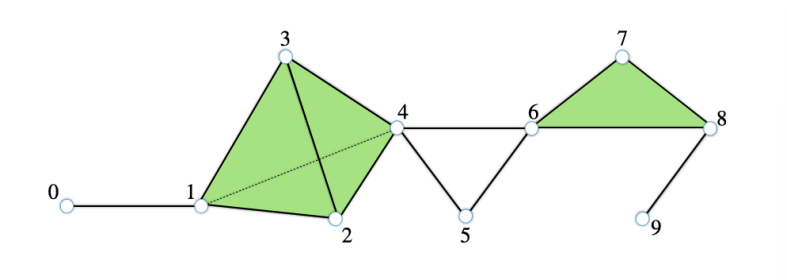


In [10]:
complejo2 = Complejo_simplicial([Simplice([0,1]), Simplice([1,2,3,4]), Simplice([4,5]), Simplice([5,6]), 
                                 Simplice([4,6]), Simplice([6,7,8]), Simplice([8,9])])

### CONJUNTO DE TODAS SUS CARAS

In [11]:
complejo2.print_caras()

Caras del complejo: [(0,), (0, 1), (1,), (1, 2), (1, 2, 3), (1, 2, 3, 4), (1, 2, 4), (1, 3), (1, 3, 4), (1, 4), (2,), (2, 3), (2, 3, 4), (2, 4), (3,), (3, 4), (4,), (4, 5), (4, 6), (5,), (5, 6), (6,), (6, 7), (6, 7, 8), (6, 8), (7,), (7, 8), (8,), (8, 9), (9,)]


### DIMENSIÓN

In [12]:
complejo2.dimension()

Dimensión del complejo: 3


### 1-ESQUELETO

In [13]:
complejo2.j_esqueleto(1)

1-esqueleto del complejo: [(0,), (0, 1), (1,), (1, 2), (1, 3), (1, 4), (2,), (2, 3), (2, 4), (3,), (3, 4), (4,), (4, 5), (4, 6), (5,), (5, 6), (6,), (6, 7), (6, 8), (7,), (7, 8), (8,), (8, 9), (9,)]


[(0,),
 (0, 1),
 (1,),
 (1, 2),
 (1, 3),
 (1, 4),
 (2,),
 (2, 3),
 (2, 4),
 (3,),
 (3, 4),
 (4,),
 (4, 5),
 (4, 6),
 (5,),
 (5, 6),
 (6,),
 (6, 7),
 (6, 8),
 (7,),
 (7, 8),
 (8,),
 (8, 9),
 (9,)]

### ESTRELLA DEL VÉRTICE 4

In [14]:
complejo2.estrella([4])

Estrella de [4]: [(1, 2, 3, 4), (1, 2, 4), (1, 3, 4), (1, 4), (2, 3, 4), (2, 4), (3, 4), (4,), (4, 5), (4, 6)]


### LINK DEL VÉRTICE 4

In [15]:
complejo2.link([4])

Link de [4]: [(1,), (1, 2), (1, 2, 3), (1, 3), (2,), (2, 3), (3,), (5,), (6,)]


### CARACTERÍSTICA DE EULER

In [17]:
complejo2.Euler()

Característica de Euler: 0


### NÚMERO DE COMPONENTES CONEXAS

In [19]:
complejo2.connected_components()

1

## PRÁCTICA 1: CLASE 3 FILTRACIÓN DE COMPLEJOS SIMPLICIALES

### FUNCIÓN INSERTAR (DENTRO DE LA CLASE COMPLEJO SIMPLICIAL)

In [ ]:
    # Función para añadir un símplice a nuestro complejo
    def insert(self, simplices):
        for s in simplices:
            # Evitamos añadir símplices repetidos, comprobando si tiene los mismos vértices
            if any(set(s.vertices) == set(existing.vertices) for existing in self.simplices):
                continue
            # Eliminamos las caras que ya estén contenidas en el simplice que queremos añadir para evitar duplicados
            to_remove = [existing for existing in self.simplices if set(existing.vertices).issubset(set(s.vertices))]
            for r in to_remove:
                self.simplices.remove(r)
            self.simplices.add(s)
        self.c = self.calcular_caras()  # volvemos a calcular las caras
        self.d = max(s.dimension for s in self.simplices) if self.simplices else 0  # volvemos a calcular la dimensión

#### PARA HACER LOS COMPLEJOS SIMPLICIALES FILTRADOS NOS HEMOS CREADO DOS NUEVAS CLASES:
### CLASE SIMPLICE FILTRADO

In [ ]:
# Clase heredada de la clase Símplce
class Simplice_filtrado(Simplice):
    # Recibe los vértices y un float que será el índice de ese símplice (el momento en el que nace)
    def __init__(self, vertices, index):
        super().__init__(vertices)
        self.index = float(index)

    def n_caras(self, n):
        if n < 0 or n > self.dimension:
            return Exception
        else:
            caras_n = sorted(set([cara for cara in self.caras if len(cara) == n+1]), key=lambda x: x)
            return caras_n

### CLASE COMPLEJO SIMPLICIAL FILTRADO

In [ ]:
class Complejo_simplicial_filtrado(Complejo_simplicial):
    def __init__(self, simplices_filtrados):
        # Comprobamos que todos los elementos son de tipo Simplice_filtrado
        for s in simplices_filtrados:
            if not isinstance(s, Simplice_filtrado):
                raise ValueError("Todos los elementos deben ser de tipo Simplice_filtrado")
        super().__init__(simplices_filtrados)
        # Ordenamos los símplices primero por índice de filtrado y luego por dimensión
        self.update_simplices_ordenados()

#### Sobre esta clase definimos las siguientes funciones

### FUNCION PARA INSERTAR UN SIMPLICE FILTRADO

In [ ]:
    def update_simplices_ordenados(self):
        # Ordenamos los simplices por índice, en caso de coincidir por dimension, y en caso de volver a coincidir por
        # el número del vértice
        self.simplices_ordenados = sorted(self.simplices, key=lambda x: (x.index, x.dimension, x.vertices))

    # Insertar un conjunto de símplices con el mismo índice de filtrado
    def insert_filtrado(self, simplices, index):
        for s in simplices:
            s1 = Simplice_filtrado(s.vertices, index)
            # Si ya existe un símplice con los mismos vértices, mantenemos el de menor índice
            if any(set(s1.vertices) == set(existing.vertices) for existing in self.simplices):
                e = [existing for existing in self.simplices if set(s1.vertices) == set(existing.vertices)][0]
                if s1.index < e.index:  # En principio esto no sería necesario porque los simplices se añaden de manera incremental
                    self.simplices.remove(e)
                else:
                    continue
            self.simplices.add(s1)
        # Volvemos a calcular las caras y la dimensión del complejo al añadir nuevos símplices
        self.c = self.calcular_caras()
        self.d = max(s.dimension for s in self.simplices) if self.simplices else 0
        self.update_simplices_ordenados() # volvemos a ordenar los símplices

### EJEMPLO 1

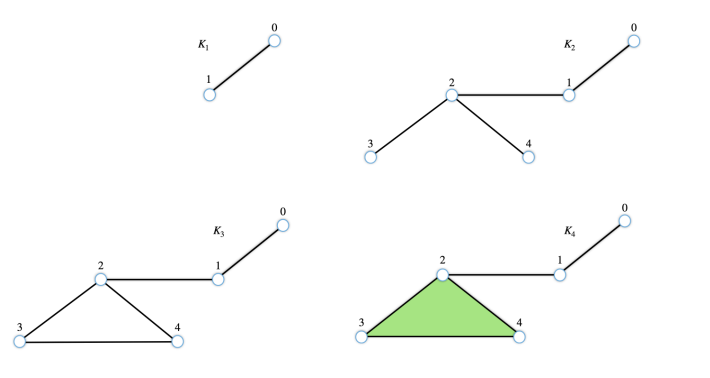

In [28]:
complejo_filtrado = Complejo_simplicial_filtrado([])
complejo_filtrado.insert_filtrado([Simplice([0,1])], 1.0)
complejo_filtrado.insert_filtrado([Simplice([1,2]), Simplice([2,3]), Simplice([2,4])], 2.0)
complejo_filtrado.insert_filtrado([Simplice([3,4])],3.0)
complejo_filtrado.insert_filtrado([Simplice([2,3,4])],4.0)

# Devolvemos el conjunto de todas las caras del complejo simplicial
complejo_filtrado.print_caras()

Caras del complejo: [(0,), (0, 1), (1,), (1, 2), (2,), (2, 3), (2, 3, 4), (2, 4), (3,), (3, 4), (4,)]


### FUNCION PARA VER LOS SIMPLICES INSERTADOS EN TIEMPO K

In [ ]:
    # Función que devuelve ordenadamente aquellos símplices cuyo indice es menor o igual al parámetro de la función
    def simplices_por_filtrado_aux(self, index):
        sf = sorted([s for s in self.simplices if s.index <= index], key=lambda x: (x.index, x.dimension))
        return sf

    # Usamos la función auxiliar para calcular los símplices con índice de filtrado menor o igual a index
    # y luego los imprimimos
    def simplices_por_filtrado(self, index):
        sf = self.simplices_por_filtrado_aux(index)
        print(f"Símplices con índice de filtrado menor o igual a {index}: {[ (s.vertices, s.index) for s in sf ]}")
        return sf

In [29]:
# En nuestro ejemplo:
K1=complejo_filtrado.simplices_por_filtrado(1.0)
K2=complejo_filtrado.simplices_por_filtrado(2.0)
K3=complejo_filtrado.simplices_por_filtrado(3.0)
K4=complejo_filtrado.simplices_por_filtrado(4.0)

Símplices con índice de filtrado menor o igual a 1.0: [([0, 1], 1.0)]
Símplices con índice de filtrado menor o igual a 2.0: [([0, 1], 1.0), ([1, 2], 2.0), ([2, 4], 2.0), ([2, 3], 2.0)]
Símplices con índice de filtrado menor o igual a 3.0: [([0, 1], 1.0), ([1, 2], 2.0), ([2, 4], 2.0), ([2, 3], 2.0), ([3, 4], 3.0)]
Símplices con índice de filtrado menor o igual a 4.0: [([0, 1], 1.0), ([1, 2], 2.0), ([2, 4], 2.0), ([2, 3], 2.0), ([3, 4], 3.0), ([2, 3, 4], 4.0)]


### PRÁCTICA 2: CLASE 4 VIETORIS RIPS Y ALPHA COMPLEJO

### CLASE PUNTO:

In [ ]:
# Añadimos la clase Punto, la cual contiene los campos vértice y coordenadas, ya que es necesario a partir de aquí
# tener las coordenadas de cada vértice.
class Punto:
    def __init__(self, nombre, coords):
        self.vertice = nombre
        self.coords = np.array(coords)

    def distancia(self, otro):
        return np.linalg.norm(self.coords - otro.coords)

    def __repr__(self):
        return f"{self.vertice}{tuple(self.coords)}"

### CLASE COMPLEJO DE VIETORIS RIPS

In [ ]:
# Clase de Complejo de Vietoris-Rips
class Complejo_Vietoris_Rips:
    def __init__(self, points):
        self.puntos = points  # points es una lista de objetos Punto
        self.space_dimension = len(points[0].coords) if points else 0 # Dimensión del espacio en el que están los puntos
    

#### Esta clase tiene las siguientes funciones:

### FUNCION PARA CALCULAR VR(r)

In [ ]:
    # Funcion para calcular el r-complejo de Vietori-Rips
    def r_complex_aux(self, r):
        complex = Complejo_simplicial_filtrado([])
        simplices = []
        for i in range(1, self.space_dimension + 2): # El simplice más grande es con n+1 puntos
            for c in combinations(self.puntos, i): # Todas las combinaciones de i puntos
                if self.verifica_radio(c, r): # dist <= 2r
                    simplices.append(Simplice_filtrado(self.vertices(c), r))
        complex.insert_filtrado(simplices, r) # Los añadimos con tiempo r
        return complex

    def r_complex(self, r):
        complex = self.r_complex_aux(r)
        print(f"Complejo de Vietoris-Rips para r = {r}: {[ (s.vertices, s.index) for s in complex.simplices_ordenados ]}")
        return complex

    # Comprueba que no haya ninguna distancia entre puntos mayor a 2r
    # Ya que el diametro del simplice que se está comprobando debe ser su diametro (el supremo de las distancias de los vértices)
    # menor o igual a 2r para añadirse al complejo de Vietori-Rips de valor r.
    def verifica_radio(self, puntos, r):
        for p1, p2 in combinations(puntos, 2):
            if p1.distancia(p2) > 2 * r: # dist <= 2r
                return False
        return True

    def vertices(self, puntos):
        return [p.vertice for p in puntos]
    

### EJEMPLO VR
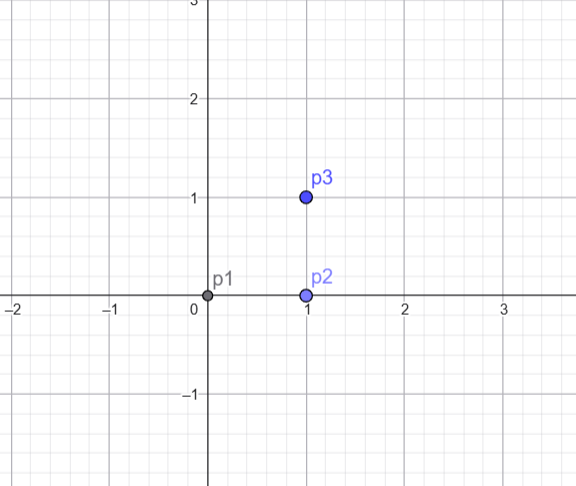

In [30]:
vr = Complejo_Vietoris_Rips([Punto(0, (0,0)), Punto(1, (1,0)), Punto(2, (0,1)), Punto(3, (1,1))])
vr.r_complex(0)
vr.r_complex(0.25)
vr.r_complex(0.5)
vr.r_complex(1)
    

Complejo de Vietoris-Rips para r = 0: [([0], 0.0), ([1], 0.0), ([2], 0.0), ([3], 0.0)]
Complejo de Vietoris-Rips para r = 0.25: [([0], 0.25), ([1], 0.25), ([2], 0.25), ([3], 0.25)]
Complejo de Vietoris-Rips para r = 0.5: [([0], 0.5), ([1], 0.5), ([2], 0.5), ([3], 0.5), ([0, 1], 0.5), ([0, 2], 0.5), ([1, 3], 0.5), ([2, 3], 0.5)]
Complejo de Vietoris-Rips para r = 1: [([0], 1.0), ([1], 1.0), ([2], 1.0), ([3], 1.0), ([0, 1], 1.0), ([0, 2], 1.0), ([0, 3], 1.0), ([1, 2], 1.0), ([1, 3], 1.0), ([2, 3], 1.0), ([0, 1, 2], 1.0), ([0, 1, 3], 1.0), ([0, 2, 3], 1.0), ([1, 2, 3], 1.0)]


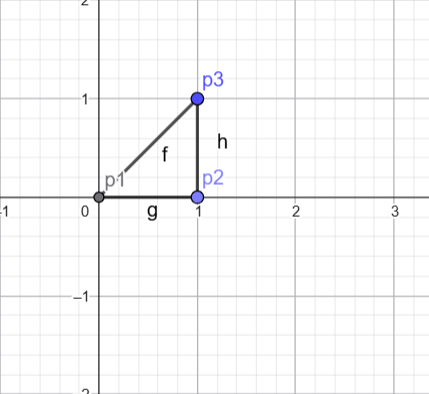 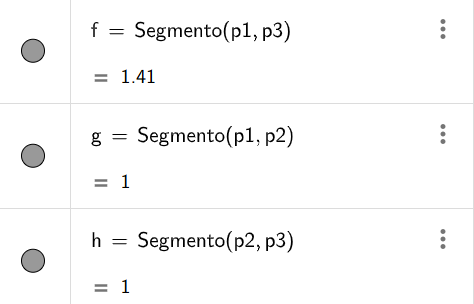

### EJEMPLO 2 VR

In [33]:
# Definimos los puntos:
points = np.random.rand(5,2)
puntos = [Punto(i, points[i]) for i in range(len(points))]
print(f'Los puntos son: {puntos}')
vr = Complejo_Vietoris_Rips(puntos)
vr.r_complex(0)
vr.r_complex(0.25)
vr.r_complex(0.5)
vr.r_complex(1)


Los puntos son: [0(np.float64(0.20321427727717767), np.float64(0.9296734955773673)), 1(np.float64(0.32976604884209226), np.float64(0.03989383374721944)), 2(np.float64(0.4678092678122928), np.float64(0.17509642298213712)), 3(np.float64(0.7079895084893957), np.float64(0.9999691061058678)), 4(np.float64(0.869229339314486), np.float64(0.7903262448988168))]
Complejo de Vietoris-Rips para r = 0: [([0], 0.0), ([1], 0.0), ([2], 0.0), ([3], 0.0), ([4], 0.0)]
Complejo de Vietoris-Rips para r = 0.25: [([0], 0.25), ([1], 0.25), ([2], 0.25), ([3], 0.25), ([4], 0.25), ([1, 2], 0.25), ([3, 4], 0.25)]
Complejo de Vietoris-Rips para r = 0.5: [([0], 0.5), ([1], 0.5), ([2], 0.5), ([3], 0.5), ([4], 0.5), ([0, 1], 0.5), ([0, 2], 0.5), ([0, 3], 0.5), ([0, 4], 0.5), ([1, 2], 0.5), ([1, 4], 0.5), ([2, 3], 0.5), ([2, 4], 0.5), ([3, 4], 0.5), ([0, 1, 2], 0.5), ([0, 1, 4], 0.5), ([0, 2, 3], 0.5), ([0, 2, 4], 0.5), ([0, 3, 4], 0.5), ([1, 2, 4], 0.5), ([2, 3, 4], 0.5)]
Complejo de Vietoris-Rips para r = 1: [([0], 

### CLASE ALPHA COMPLEJO

In [ ]:
class AlfaComplejo:
    def __init__(self, points, radius):
        self.puntos = points  # points es una lista de objetos Punto
        self.coords_puntos = np.array([p.coords for p in points])  # matriz de coordenadas
        self.complex = self.alfa_complejo(radius)
        self.radius = radius  # radio actual del alpha complejo
        self.d = self.complex.d  # dimensión del complejo

### FUNCIONES PARA CALCULAR EL ALPHA COMPLEJO

In [ ]:
    # Funcion para calcular el radio del circuncirculo del triángulo de vértices A,B y C
    def r_circuncirculo(self, s, puntos):
        A = puntos[s[0]].coords
        B = puntos[s[1]].coords
        C = puntos[s[2]].coords
        # Calcular el circuncentro y el radio
        # M1 y M2 son los puntos medios de los segmentos AB y BC respectivamente
        # m1 y m2 son las pendientes de las mediatrices
        M1 = (A + B) / 2
        # si un segmento es vertical asignamos None para evitar divisiones por 0
        m1 = (B[1] - A[1])/(B[0] - A[0]) if (B[0] - A[0]) != 0 else None
        M2 = (B + C) / 2
        # si un segmento es vertical asignamos None para evitar divisiones por 0
        m2 = (C[1] - B[1])/(C[0] - B[0]) if (C[0] - B[0]) != 0 else None
        if m1 is not None and m2 is not None:
            # Coordenadas del centro del circuncirculo
            x_circ = (m1 * M1[0] - m2 * M2[0] + M2[1] - M1[1]) / (m1 - m2)
            y_circ = m1 * (x_circ - M1[0]) + M1[1]
            # radio del circuncirculo (distancia del centro a uno de los vertices)
            r = np.linalg.norm([x_circ - A[0], y_circ - A[1]])
            return r
        return None

    def alfa_complejo(self, r):
        # Sacamos la triangulacion de Delaunay, que viene importada de la biblioteca scipy.spatial
        Del = Delaunay(self.coords_puntos)  
        simplices = []
        for s in Del.simplices:  # lista de triángulos de Delaunay
            radio_circuncirculo = self.r_circuncirculo(s, self.puntos)
            # Un triángulo de Delaunay pertenece a Aplpha(r) si y solo si r es mayor o igual que el radio de la
            # circnferencia que pasa por los tres puntos del triángulo de Delaunay
            if radio_circuncirculo is not None and radio_circuncirculo <= r:
                simplices.append(Simplice_filtrado([s[0], s[1], s[2]], r))
            # Comprobamos las aristas
            else:
                arr_dist_aristas = [self.puntos[s[i]].distancia(self.puntos[s[(i+1)%3]]) for i in range(3)] # [6 3 9] -> [63 39 96] -> [dist(6,3), dist(3,9), dist(9,6)]
                for i in range(3):
                    d = arr_dist_aristas[i]
                    if d <= 2*r: # Primer caso de aristas
                        simplices.append(Simplice_filtrado(sorted([s[i], s[(i+1)%3]]), r))
                        # No hay segundo caso ya que la arista se añadira con el triangulo, y puesto que hemos comprobado antes si se añade el triángulo o no
                        # no hace falta volver a comprobarlo.
                    else: # Si no están ni la arista ni el triángulo, añadimos solo los vértices
                        simplices.append(Simplice_filtrado([s[i]], r))
        # Comprobamos que no haya ninguna cara que ya sea añadida por otra del complejo
        s_aux = []
        # Recorremos los símplices ordenados por dimensión decreciente
        for s in sorted(simplices, key=lambda x: len(x.vertices), reverse=True):
            # Una cara ya está añadida si sus vértices son un subconjunto de los vértices de algún símplice ya añadido
            if any(set(s.vertices).issubset(set(existing.vertices)) for existing in s_aux):
                continue
            # Si no está añadida, la añadimos
            s_aux.append(s)
        complejo = Complejo_simplicial_filtrado([])
        complejo.insert_filtrado(s_aux, r)
        return complejo

### FUNCIONES PARA HACER LOS PLOTS DE LOS ALPHA COMPLEJOS

In [ ]:
    # Funcion para mostrar voronoi y Delaunay copiada de los ejemplos
    def show_voronoi_delaunay(self):
        # Usamos la librería scipy.spatial para Voronoi, Delaunay y voronoi_plot_2d
        vor = Voronoi(self.coords_puntos)
        Del = Delaunay(self.coords_puntos)
        fig = voronoi_plot_2d(vor,show_vertices=False,line_width=2, line_colors='blue' )
        c=np.ones(len(self.coords_puntos))
        cmap = matplotlib.colors.ListedColormap("limegreen")
        plt.tripcolor(self.coords_puntos[:,0],self.coords_puntos[:,1],Del.simplices, c, edgecolor="k", lw=2,
        cmap=cmap)
        plt.plot(self.coords_puntos[:,0], self.coords_puntos[:,1], 'ko')
        plt.show()

    # Dibuja el diagrama de Voronoi junto con el alfa-complejo
    def show_voronoi_alfa(self):
        # Usamos la librería scipy.spatial para Voronoi y voronoi_plot_2d
        vor = Voronoi(self.coords_puntos)
        fig = voronoi_plot_2d(vor, show_vertices=False, line_width=2, line_colors='blue')
        # Ya dibujado el diagrama de Voronoi, dibujamos el alfa-complejo
        p = self.coords_puntos
        aristas = set()
        triangulos = set()
        for s in self.complex.simplices_ordenados:
            # Intentamos extraer las aristas y triángulos
            try:
                for e in s.n_caras(1):
                    aristas.add(tuple(int(v) for v in e))
                for t in s.n_caras(2):
                    triangulos.add(tuple(int(v) for v in t))
            except Exception:
                pass
        # Dibujamos los triángulos si existen
        if triangulos:
            for tri in triangulos:
                coords = p[list(tri)]
                plt.fill(coords[:, 0], coords[:, 1], facecolor='limegreen', edgecolor='k', alpha=0.3)
        # Dibujamos las aristas, incluidas las que ya dibujo el triangulo para que todas tengan la misma forma
        if aristas:
            for edge in aristas:
                xs = p[list(edge), 0]
                ys = p[list(edge), 1]
                plt.plot(xs, ys, color='k', linewidth=2)
        # Por ultimo dibujamos los puntos
        plt.plot(p[:, 0], p[:, 1], 'ko')
        # Obtenemos el sistema de coordenadas haciendo que una unidad en x valga lo mismo que una en y
        plt.gca().set_aspect('equal', adjustable='box')
        plt.show()

### PRINTS DE LOS ALPHA COMPLEJOS

In [ ]:
    # Imprime el complejo alfa
    def print_complex(self):
        print(f"Alfa-complejo con radio {self.radius}: {[ (s.vertices, s.index) for s in self.complex.simplices_ordenados ]}")
        return self.complex

    def print_points(self):
        print("Puntos del alfa-complejo:")
        for pt in self.puntos:
            x, y = pt.coords
            print(f"{pt.vertice}: ({float(x):.4f}, {float(y):.4f})")
        return self.puntos

### EJEMPLO ALPHA COMPLEJO

Alfa-complejo con radio 0.25: [([0, 3], 0.25), ([0, 9], 0.25), ([1, 2], 0.25), ([2, 4], 0.25), ([2, 5], 0.25), ([2, 6], 0.25), ([2, 7], 0.25), ([2, 8], 0.25), ([3, 4], 0.25), ([3, 6], 0.25), ([3, 9], 0.25), ([4, 5], 0.25), ([4, 7], 0.25), ([5, 7], 0.25), ([1, 6, 0], 0.25), ([8, 1, 0], 0.25)]


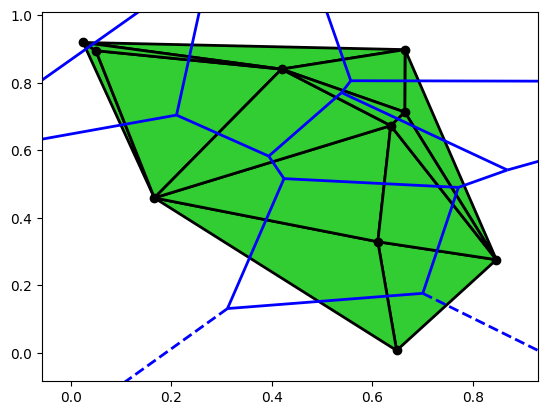

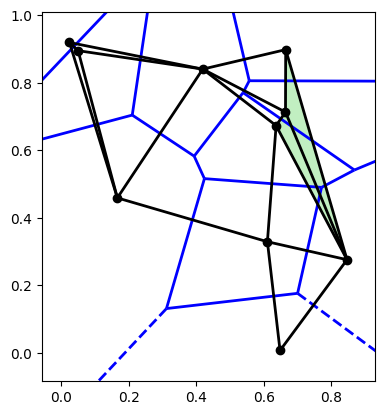

In [37]:
points = np.random.rand(10,2)
puntos = [Punto(i, points[i]) for i in range(len(points))]
ac = AlfaComplejo(puntos, 0.25)
ac.print_complex()
# ac.print_points()
ac.show_voronoi_delaunay()
ac.show_voronoi_alfa()